<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/DMD_currency_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import math
import statistics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
from scipy.linalg import svd
import warnings

In [ ]:
df_1 = pd.read_csv("通貨データセット1.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
length = len(df_1)
df_1

,USDJPY,EURJPY,EUDUSD,AUDUSD,AUDJPY,AUDEUR,GBPUSD,EURGBP
0,102.805,126.27,1.22825,0.77345,79.515,0.6297,1.36910,0.89712
1,102.915,126.31,1.22735,0.77115,79.363,0.6283,1.35620,0.90499
2,102.825,126.74,1.23255,0.77895,80.096,0.6320,1.36290,0.90436
3,103.385,127.12,1.22955,0.77755,80.387,0.6324,1.36095,0.90345
4,103.965,127.11,1.22255,0.77655,80.734,0.6352,1.35790,0.90032
...,...,...,...,...,...,...,...,...
769,142.235,156.50,1.10070,0.67890,96.528,0.6168,1.27020,0.86656
770,142.385,156.83,1.10145,0.68000,96.822,0.6174,1.26895,0.86800
771,142.635,157.55,1.10460,0.68260,97.363,0.6180,1.27005,0.86973
772,140.855,156.64,1.11200,0.68390,96.337,0.6150,1.28050,0.86841


In [ ]:
df_1 = pd.read_csv("通貨データセット1.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
length = len(df_1)
df_1
y_df = df_1
#y_df = y_df.drop('USDJPY',axis=1)
#y_df = y_df.drop('EURJPY',axis=1)
y_df = y_df.drop('EUDUSD',axis=1)
y_df = y_df.drop('AUDUSD',axis=1)
#y_df = y_df.drop('AUDJPY',axis=1)
y_df = y_df.drop('AUDEUR',axis=1)
y_df = y_df.drop('GBPUSD',axis=1)
y_df = y_df.drop('EURGBP',axis=1)
y_df

,USDJPY,EURJPY,AUDJPY
0,102.805,126.27,79.515
1,102.915,126.31,79.363
2,102.825,126.74,80.096
3,103.385,127.12,80.387
4,103.965,127.11,80.734
...,...,...,...
769,142.235,156.50,96.528
770,142.385,156.83,96.822
771,142.635,157.55,97.363
772,140.855,156.64,96.337


In [ ]:
#y_df = y_df.iloc[::-1]
#y_df.index = range(len(y_df))
#y_df

<Axes: >

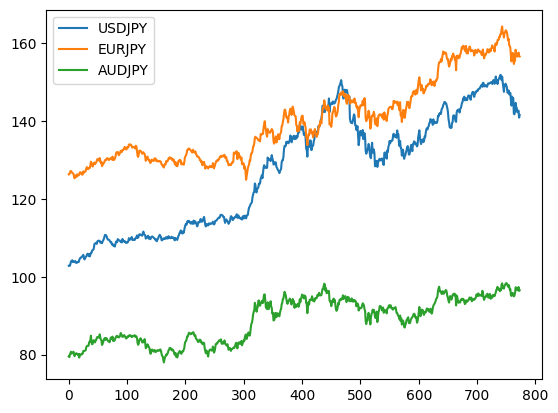

In [ ]:
y_df.plot()

In [ ]:
selected_column1 = "USDJPY"
selected_column2 = "EURJPY"
selected_column3 = "AUDJPY"
first_val1 =df_1[selected_column1][0]
comission1 = 0.1/first_val1
first_val2 =df_1[selected_column2][0]
comission2 = 0.1/first_val2
first_val3 =df_1[selected_column3][0]
comission3 = 0.1/first_val3
y_df[selected_column1] = y_df[selected_column1]/first_val1
y_df[selected_column2] = y_df[selected_column2]/first_val2
y_df[selected_column3] = y_df[selected_column3]/first_val3
y_df

,USDJPY,EURJPY,AUDJPY
0,1.000000,1.000000,1.000000
1,1.001070,1.000317,0.998088
2,1.000195,1.003722,1.007307
3,1.005642,1.006732,1.010966
4,1.011283,1.006652,1.015330
...,...,...,...
769,1.383542,1.239408,1.213960
770,1.385001,1.242021,1.217657
771,1.387433,1.247723,1.224461
772,1.370118,1.240516,1.211558


In [ ]:
class DynamicModeDecomposition:
    def __init__(self, rank=None, svd_rank=None,T=None):
        """
        動的モード分解（DMD）クラス
        論文 "Dynamic mode decomposition of numerical and experimental data" に基づく実装

        Parameters:
        rank: DMDで使用するランク（Noneの場合は自動決定）
        svd_rank: SVDで使用するランク（Noneの場合は自動決定）
        """
        self.rank = rank
        self.svd_rank = svd_rank
        self.modes = None
        self.eigenvalues = None
        self.amplitudes = None
        self.Phi = None  # DMDモード
        self.omega = None  # 連続時間固有値
        self.b = None  # 初期振幅
        self.A_tilde = None  # 低次元線形演算子
        self.T = T

    def fit(self, X, dt=1.0):
        """
        DMDアルゴリズムを実行

        Parameters:
        X: データ行列 (n_features x n_timesteps)
        dt: 時間刻み
        """
        # Step 1: データをX1とX2に分割
        X1 = X[:, :-1]  # x_1, x_2, ..., x_{m-1}
        X2 = X[:, 1:]   # x_2, x_3, ..., x_m

        # Step 2: X1のSVD分解
        U, s, Vt = svd(X1, full_matrices=False)

        # Step 3: ランクの決定とtruncation
        if self.svd_rank is None:
            # 特異値の閾値による自動ランク決定
            tolerance = 1e-10
            self.svd_rank = np.sum(s > tolerance)

        r = min(self.svd_rank, len(s))
        U_r = U[:, :r]
        s_r = s[:r]
        V_r = Vt[:r, :].T

        # Step 4: 低次元線形演算子A_tildeの計算
        self.A_tilde = U_r.T @ X2 @ V_r @ np.diag(1/s_r)
        #self.A_tilde = U_r.T @ X2 @ V_r @ np.linalg.pinv(s_r)

        # Step 5: A_tildeの固有値分解
        eigenvals, W = np.linalg.eig(self.A_tilde)

        # Step 6: DMDモードの計算
        self.Phi = X2 @ V_r @ np.diag(1/s_r) @ W
        #self.Phi = X2 @ V_r @ np.linalg.pinv(s_r) @ W

        # 離散時間固有値
        self.eigenvalues = eigenvals

        # 連続時間固有値（論文の式に基づく）
        #self.omega = np.log(eigenvals) / dt
        self.omega = eigenvals #dt=1の場合 expがpredictのところで入れていないためlog入れていない

        # Step 7: 初期振幅の計算
        self.b = np.linalg.pinv(self.Phi) @ X[:, 0]

        # 使用するモード数の決定
        if self.rank is None:
            self.rank = r
        else:
            self.rank = min(self.rank, r)

        return self

    def predict(self, t_eval, x0=None):
        """
        指定された時刻での状態を予測

        Parameters:
        t_eval: 評価時刻
        x0: 初期条件（Noneの場合は学習データの初期条件を使用）

        Returns:
        X_pred: 予測された状態 (n_features )
        """
        if self.Phi is None:
            raise ValueError("まずfit()を実行してください")

        if x0 is not None:
            # 新しい初期条件での振幅計算
            b = np.linalg.pinv(self.Phi) @ x0
        else:
            b = self.b
        t_ = self.T + t_eval

        # 時間発展の計算
        # x(t) = Φ * diag(b) * exp(ω*t)

        time_evolution = np.array(self.omega[:self.rank, np.newaxis] **t_)

        # 予測
        X_pred = self.Phi[:, :self.rank] @ (b[:self.rank, np.newaxis] * time_evolution)

        return X_pred

    def compute_dmd_solution(self, t_eval, mode_indices=None):
        """
        特定のモードのみを使用したDMD解を計算

        Parameters:
        t_eval: 評価時刻
        mode_indices: 使用するモードのインデックス（Noneの場合は全モード）
        """
        if mode_indices is None:
            mode_indices = range(self.rank)

        time_evolution = np.exp(np.outer(self.omega[mode_indices], t_eval))
        X_dmd = self.Phi[:, mode_indices] @ (self.b[mode_indices, np.newaxis] * time_evolution)

        return X_dmd

In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp

magic_num = 180
estimate_num = 150
predict_time = 30


comission = comission3
amendment = first_val3

df_array = y_df.to_numpy()


for i in range(1,5):
  total_num = 100*i
  print(total_num)

  total_list = []
  y_list = []
  current_list = []
  result_list = []
  predict_flag2 = 0
  change_num = 0
  for j in range(magic_num-1,len(df_array)):
    X_return_list = []
    for k in range(1,magic_num):
      X_return_list.append(df_array[j-k])
    y_return = (df_array[j]-df_array[j-1])*1
    current_list.append(df_array[j-1])
    y_list.append(y_return)
    X_list2 = list(reversed(X_return_list))
    total_list.append(X_list2)

  total_list = np.array(total_list)
  y_list = np.array(y_list)
  current_list = np.array(current_list)
  #print(total_list)
  #print(total_list.shape)
  #print(y_list.shape)
  for j in range(len(total_list)):
    if j <= len(total_list)-1-total_num:
      continue
    #print(j)
    X_array = np.array(total_list[j])
    y_array = y_list[j]
    current_X = np.array(current_list[j])
    #print(X_array.shape)
    #print(y_array.shape)
    #print("#")

    #この後Xを転置してDMDに突っ込む
    X_DMD = X_array.T
    dmd = DynamicModeDecomposition(rank=15, svd_rank=2,T=magic_num)

    dmd.fit(X_DMD)
    X_pred = dmd.predict(predict_time)
    #print(X_pred.real)

    y_pred = X_pred[2,0].real
    #print(y_pred
    current_y = current_X[2]
    retrun_ = y_array[2]
    #print(current_y)

    if y_pred - current_y >= 0.0000:
      predict_flag = -1
    elif y_pred - current_y <-0.0000:
      predict_flag = 1
    else:
      predict_flag = predict_flag2

    if predict_flag*predict_flag2 >=0 :
      result_r = retrun_*predict_flag
      result_list.append(result_r)
      predict_flag2 = predict_flag
    else:
      result_r = retrun_*predict_flag-comission
      #result_r = retrun_*predict_flag-0
      result_list.append(result_r)
      predict_flag2 = predict_flag
      change_num +=1
      #print("change_point:",j)

  R_sum = sum(result_list)*amendment
  SR = np.mean(np.array(result_list))/np.std(np.array(result_list))
  print("SharpRatio:",SR)
  print(R_sum)
  print("change_num:",change_num)

100
SharpRatio: 0.038597140543617334
2.1120000000000085
change_num: 3
200
SharpRatio: -0.04302089325901185
-5.542000000000028
change_num: 21
300
SharpRatio: -0.021696294950883533
-4.595999999999977
change_num: 35
400
SharpRatio: -0.0010881488248717572
-0.31400000000000716
change_num: 39


In [ ]:
#移動平均考慮バージョン
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp


magic_num = 180
estimate_num = 150
mean_num = 150
predict_time = 30


comission = comission3
amendment = first_val3
df_array = y_df.to_numpy()


for i in range(1,5):
  total_num = 100*i
  print(total_num)

  total_list = []
  y_list = []
  current_list = []
  result_list = []
  predict_flag = 0
  predict_flag2 = 0
  for j in range(magic_num-1,len(df_array)):
    X_return_list = []
    for k in range(1,magic_num):
      X_return_list.append(df_array[j-k])
    y_return = (df_array[j]-df_array[j-1])*1
    current_list.append(df_array[j-1])
    y_list.append(y_return)
    X_list2 = list(reversed(X_return_list))
    total_list.append(X_list2)

  total_list = np.array(total_list)
  y_list = np.array(y_list)
  current_list = np.array(current_list)
  #print(total_list)
  #print(total_list.shape)
  #print(y_list.shape)
  for j in range(len(total_list)):
    if j <= len(total_list)-1-total_num:
      continue
    #print(j+magic_num-1)
    X_array = np.array(total_list[j])
    #print(X_array)
    mean_list = []
    for l in range(len(X_array)-mean_num,len(X_array)):
      mean_list.append(X_array[l][2])#二番目を変える

    y_array = y_list[j]
    current_X = np.array(current_list[j])
    mean_X = np.mean(np.array(mean_list))
    #print(mean_list)
    #print(mean_X)
    #print(X_array.shape)
    #print(y_array.shape)
    #print("#")

    #この後Xを転置してDMDに突っ込む
    X_DMD = X_array.T
    dmd = DynamicModeDecomposition(rank=15, svd_rank=2,T=magic_num)

    dmd.fit(X_DMD)
    X_pred = dmd.predict(predict_time)
    #print(X_pred.real)

    y_pred = X_pred[2,0].real
    #print(y_pre
    current_y = current_X[2]
    retrun_ = y_array[2]
    #print(current_y)

    if y_pred - current_y >= 0.0000:
      if mean_X < current_y:
        predict_flag = -1
    elif y_pred - current_y <-0.0000:
      if mean_X > current_y:
        predict_flag = 1
    else:
      predict_flag = 0

    if predict_flag==predict_flag2:
      result_r = retrun_*predict_flag
      result_list.append(result_r)
      predict_flag2 = predict_flag
    else:
      result_r = retrun_*predict_flag-comission
      result_list.append(result_r)
      predict_flag2 = predict_flag
      print("change_point:",j)

  R_sum = sum(result_list)*amendment
  SR = np.mean(np.array(result_list))/np.std(np.array(result_list))
  print("SharpRatio:",SR)
  print(R_sum)

100
change_point: 495
change_point: 585
SharpRatio: 0.011982019126111423
0.6580000000000045
200
change_point: 396
change_point: 423
change_point: 426
change_point: 429
change_point: 430
change_point: 435
change_point: 585
SharpRatio: 0.048747993022308596
6.238000000000001
300
change_point: 295
change_point: 298
change_point: 300
change_point: 340
change_point: 423
change_point: 426
change_point: 429
change_point: 430
change_point: 435
change_point: 585
SharpRatio: 0.05900432997218719
12.394000000000002
400
change_point: 195
change_point: 272
change_point: 286
change_point: 298
change_point: 300
change_point: 340
change_point: 423
change_point: 426
change_point: 429
change_point: 430
change_point: 435
change_point: 585
SharpRatio: 0.05096098898253356
14.599999999999982


In [ ]:
#移動平均考慮バージョンdmdなし
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp


magic_num = 200
estimate_num = 150
mean_num = 200
predict_time = 1


comission = comission1
amendment = first_val1

df_array = y_df.to_numpy()


for i in range(1,5):
  total_num = 100*i
  print(total_num)

  total_list = []
  y_list = []
  current_list = []
  result_list = []
  predict_flag = 0
  predict_flag2 = 0
  for j in range(magic_num-1,len(df_array)):
    X_return_list = []
    for k in range(2,magic_num):
      X_return_list.append(df_array[j-k])
    y_return = (df_array[j]-df_array[j-1])*1
    current_list.append(df_array[j-1])
    y_list.append(y_return)
    X_list2 = list(reversed(X_return_list))
    total_list.append(X_list2)

  total_list = np.array(total_list)
  y_list = np.array(y_list)
  current_list = np.array(current_list)
  #print(total_list)
  #print(total_list.shape)
  #print(y_list.shape)
  for j in range(len(total_list)):
    if j <= len(total_list)-1-total_num:
      continue
    #print(j+magic_num-1)
    X_array = np.array(total_list[j])
    #print(X_array)
    mean_list = []
    for l in range(len(X_array)-mean_num,len(X_array)):
      mean_list.append(X_array[l][0])#二番目を変える

    y_array = y_list[j]
    current_X = np.array(current_list[j])
    mean_X = np.mean(np.array(mean_list))
    #print(mean_list)
    #print(mean_X)
    #print(X_array.shape)
    #print(y_array.shape)
    #print("#")

    #この後Xを転置してDMDに突っ込む
    X_DMD = X_array.T
    dmd = DynamicModeDecomposition(rank=15, svd_rank=2,T=magic_num)

    dmd.fit(X_DMD)
    X_pred = dmd.predict(predict_time)
    #print(X_pred.real)

    y_pred = X_pred[0,0].real
    #print(y_pred
    current_y = current_X[0]
    retrun_ = y_array[0]
    #print(current_y)


    if mean_X < current_y:
      predict_flag = -1
    elif mean_X > current_y:
      predict_flag = 1
    else:
      predict_flag = 0

    if predict_flag==predict_flag2:
      result_r = retrun_*predict_flag
      result_list.append(result_r)
      predict_flag2 = predict_flag
    else:
      result_r = retrun_*predict_flag-comission
      result_list.append(result_r)
      predict_flag2 = predict_flag
      print("change_point:",j)

  R_sum = sum(result_list)*amendment
  SR = np.mean(np.array(result_list))/np.std(np.array(result_list))
  print("SharpRatio:",SR)
  print(R_sum)

100
change_point: 475
change_point: 565
change_point: 568
change_point: 571
SharpRatio: 0.07148307241705937
6.054999999999934
200
change_point: 375
change_point: 403
change_point: 404
change_point: 415
change_point: 565
change_point: 568
change_point: 571
SharpRatio: 0.05216970162604066
8.58499999999992
300
change_point: 275
change_point: 299
change_point: 300
change_point: 307
change_point: 308
change_point: 311
change_point: 365
change_point: 366
change_point: 403
change_point: 404
change_point: 415
change_point: 565
change_point: 568
change_point: 571
SharpRatio: 0.1051853788450566
31.54000000000002
400
change_point: 175
change_point: 299
change_point: 300
change_point: 307
change_point: 308
change_point: 311
change_point: 365
change_point: 366
change_point: 403
change_point: 404
change_point: 415
change_point: 565
change_point: 568
change_point: 571
SharpRatio: 0.04542475835730364
18.160000000000032
